# 55B and 55C fitted curves and static renderings

Load the saved outputs from `cf.ipynb`, overlay both stitched observations and heterogeneous-line fits, and make one non-interactive 3D rendering for each sample. The 55C render uses the original box-to-mask ratios; the 55B ratios are adjusted so both rendered boxes have exactly the same visual dimensions.

In [1]:
from pathlib import Path
import sys

# Ensure cf_tools resolves the scattering implementation in smpl/, as in cf.ipynb.
SMPL_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(SMPL_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Preload the smpl implementation before the renderer adds the project root.
import rw_line_scattering as rls
import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pv.OFF_SCREEN = True

OUTPUT_DIR = Path("output/yyw")
SAMPLE_TAGS = ("55B_R0", "55C_R0")
WEIGHTFRAC_TAGS = ("1.5", "4.5")
COLORS = {"55B_R0": "#0072B2", "55C_R0": "#D55E00"}

## Load the saved observations, fit curves, and parameters

In [2]:
def load_named_values(path):
    table = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    return {str(row["name"]): float(row["value"]) for row in np.atleast_1d(table)}


observations = {
    tag: np.genfromtxt(
        OUTPUT_DIR / f"{tag}_stitched_observation.csv",
        delimiter=",",
        names=True,
    )
    for tag in SAMPLE_TAGS
}
fit_curves = {
    tag: np.genfromtxt(
        OUTPUT_DIR / f"{tag}_first_fit_curve.csv",
        delimiter=",",
        names=True,
    )
    for tag in SAMPLE_TAGS
}
fit_parameters = {
    tag: load_named_values(OUTPUT_DIR / f"{tag}_first_fit_parameters.csv")
    for tag in SAMPLE_TAGS
}

for tag in SAMPLE_TAGS:
    print(
        f"[status] {tag}: observation points={observations[tag].size}, "
        f"fit points={fit_curves[tag].size}, "
        f"mean_k={fit_parameters[tag]['mean_k']:.6g}, "
        f"k_H/k={fit_parameters[tag]['k_H_over_k']:.6g}"
    )

[status] 55B_R0: observation points=159, fit points=149, mean_k=0.0332441, k_H/k=0.0794543
[status] 55C_R0: observation points=159, fit points=149, mean_k=0.0543869, k_H/k=0.0568938


## Stitched curves and model fits on one plot

[status] saved output\55B_55C_stitched_and_model_fits.png


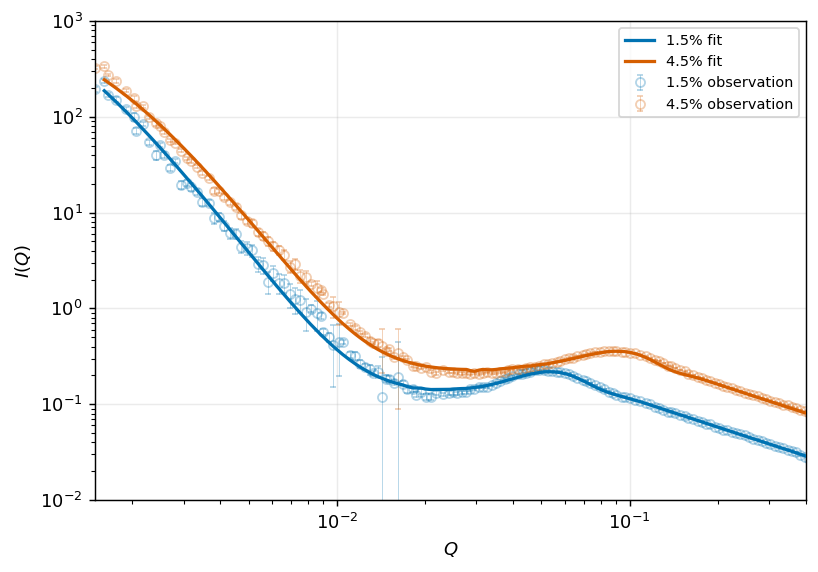

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4.5))

for tags in zip(SAMPLE_TAGS, WEIGHTFRAC_TAGS):
    tag = tags[0]
    weightfrac = tags[1]
    label = tag.split("_")[0]
    obs = observations[tag]
    fit = fit_curves[tag]
    positive = np.isfinite(obs["I"]) & (obs["I"] > 0.0)
    ax.errorbar(
        obs["Q"][positive],
        obs["I"][positive],
        yerr=obs["err"][positive],
        fmt="o",
        ms=5.0,
        lw=0.5,
        capsize=1.5,
        color=COLORS[tag],
        markerfacecolor="none",
        alpha=0.3,
        label=f"{weightfrac}% observation",
    )
    ax.plot(
        fit["Q"],
        fit["I_fit"],
        color=COLORS[tag],
        lw=1.8,
        label=f"{weightfrac}% fit",
        zorder=10,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.5e-3, 4.0e-1)
ax.set_ylim(1e-2, 1e3)
ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()

COMPARISON_PLOT = OUTPUT_DIR / "55B_55C_stitched_and_model_fits.png"
fig.savefig(COMPARISON_PLOT)
print(f"[status] saved {COMPARISON_PLOT}")

In [4]:
# Chain contour length per unit volume and estimated PSSNa weight fractions.
# rho0 is the unmasked line-length density; p_H is the retained mask fraction.
# Assumptions: Q is in angstrom^-1, one PSSNa repeat contributes 0.25 nm
# of contour, repeat molar mass is 206.19 g/mol, and glycerol-d8 density is
# 1.371 g/cm^3 at 25 C. Weight fractions assume additive dilute-solution mass.
AVOGADRO = 6.02214076e23
PSSNA_REPEAT_MOLAR_MASS_G_PER_MOL = 206.19
PSSNA_CONTOUR_INCREMENT_NM = 0.25
GLYCEROL_D8_DENSITY_G_PER_CM3 = 1.371

def pssna_mass_concentration_g_per_cm3(length_density_nm_per_nm3):
    repeat_mass_g = PSSNA_REPEAT_MOLAR_MASS_G_PER_MOL / AVOGADRO
    mass_per_contour_nm = repeat_mass_g / PSSNA_CONTOUR_INCREMENT_NM
    return length_density_nm_per_nm3 * mass_per_contour_nm * 1.0e21


def approximate_weight_percent(polymer_g_per_cm3):
    return 100.0 * polymer_g_per_cm3 / (
        GLYCEROL_D8_DENSITY_G_PER_CM3 + polymer_g_per_cm3
    )


chain_length_density_results = {}

print("Chain contour-length density (assuming Q in angstrom^-1)")
print("-" * 78)
for tag in SAMPLE_TAGS:
    params = fit_parameters[tag]
    rho0 = params["rho0"]
    p_H = params["p_H"]
    retained_density = p_H * rho0
    unmasked_nm_per_nm3 = 100.0 * rho0
    retained_nm_per_nm3 = 100.0 * retained_density
    unmasked_concentration = pssna_mass_concentration_g_per_cm3(unmasked_nm_per_nm3)
    retained_concentration = pssna_mass_concentration_g_per_cm3(retained_nm_per_nm3)
    unmasked_weight_percent = approximate_weight_percent(unmasked_concentration)
    retained_weight_percent = approximate_weight_percent(retained_concentration)

    result = {
        "rho0_A^-2": rho0,
        "unmasked_nm_per_nm3": unmasked_nm_per_nm3,
        "p_H": p_H,
        "retained_A^-2": retained_density,
        "retained_nm_per_nm3": retained_nm_per_nm3,
        "retained_m^-2": 1.0e20 * retained_density,
        "chain_mm_per_um^3": 1.0e5 * retained_density,
        "unmasked_concentration_g_per_cm3": unmasked_concentration,
        "retained_concentration_g_per_cm3": retained_concentration,
        "unmasked_weight_percent": unmasked_weight_percent,
        "retained_weight_percent": retained_weight_percent,
    }
    chain_length_density_results[tag] = result

    print(f"{tag}:")
    print(f"  unmasked rho0          = {rho0:.8g} A^-2")
    print(f"                         = {unmasked_nm_per_nm3:.8g} nm/nm^3")
    print(f"  retained fraction p_H  = {p_H:.8g}")
    print(f"  retained length/volume = {retained_density:.8g} A^-2")
    print(f"                         = {result['retained_nm_per_nm3']:.8g} nm/nm^3")
    print(f"                         = {result['retained_m^-2']:.8g} m^-2")
    print(f"                         = {result['chain_mm_per_um^3']:.6g} mm per um^3")
    print(f"  estimated PSSNa concentration (unmasked) = {unmasked_concentration:.6g} g/cm^3")
    print(f"  estimated PSSNa concentration (retained) = {retained_concentration:.6g} g/cm^3")
    print(f"  estimated PSSNa weight fraction (unmasked) = {unmasked_weight_percent:.6g} wt%")
    print(f"  estimated PSSNa weight fraction (retained) = {retained_weight_percent:.6g} wt%")

density_ratio = (
    chain_length_density_results["55C_R0"]["retained_A^-2"]
    / chain_length_density_results["55B_R0"]["retained_A^-2"]
)
print("-" * 78)
print(f"55C / 55B retained chain-length density = {density_ratio:.6g}")

# Invert the independently known sample weight fractions to estimate how much
# unresolved chemical contour is represented by each unit of fitted line length.
# A factor > 1 means the true backbone contour is longer than the fitted smooth line.
NOMINAL_PSSNA_WEIGHT_PERCENT = {"55B_R0": 1.5, "55C_R0": 4.5}

print("\nUnresolved backbone-contour estimate from nominal sample weight fractions")
print("-" * 78)
for tag in SAMPLE_TAGS:
    nominal_wt_percent = NOMINAL_PSSNA_WEIGHT_PERCENT[tag]
    nominal_mass_fraction = nominal_wt_percent / 100.0
    target_concentration = (
        nominal_mass_fraction / (1.0 - nominal_mass_fraction)
        * GLYCEROL_D8_DENSITY_G_PER_CM3
    )
    result = chain_length_density_results[tag]

    print(f"{tag}: nominal={nominal_wt_percent:.3g} wt%, target={target_concentration:.6g} g/cm^3")
    for basis in ("unmasked", "retained"):
        model_concentration = result[f"{basis}_concentration_g_per_cm3"]
        contour_factor = target_concentration / model_concentration
        effective_repeat_advance_nm = PSSNA_CONTOUR_INCREMENT_NM / contour_factor
        result[f"{basis}_unresolved_contour_factor"] = contour_factor
        result[f"{basis}_effective_repeat_advance_nm"] = effective_repeat_advance_nm
        print(
            f"  {basis:8s}: true contour / fitted line = {contour_factor:.6g}; "
            f"effective repeat advance = {effective_repeat_advance_nm:.6g} nm"
        )

Chain contour-length density (assuming Q in angstrom^-1)
------------------------------------------------------------------------------
55B_R0:
  unmasked rho0          = 0.00012509116 A^-2
                         = 0.012509116 nm/nm^3
  retained fraction p_H  = 0.78675052
  retained length/volume = 9.8415538e-05 A^-2
                         = 0.0098415538 nm/nm^3
                         = 9.8415538e+15 m^-2
                         = 9.84155 mm per um^3
  estimated PSSNa concentration (unmasked) = 0.0171318 g/cm^3
  estimated PSSNa concentration (retained) = 0.0134785 g/cm^3
  estimated PSSNa weight fraction (unmasked) = 1.23416 wt%
  estimated PSSNa weight fraction (retained) = 0.973541 wt%
55C_R0:
  unmasked rho0          = 0.00033645554 A^-2
                         = 0.033645554 nm/nm^3
  retained fraction p_H  = 0.95378912
  retained length/volume = 0.00032090763 A^-2
                         = 0.032090763 nm/nm^3
                         = 3.2090763e+16 m^-2
                 

## Static 3D renderings with a common box size

The fitted physical mask length is $L_H=1/k_H$. Since the renderer input is the ratio `box_size / mask_length`, maintaining the same physical box size as 55C requires

$$R_x = R_{55C}\,\frac{L_{H,55C}}{L_{H,x}} = R_{55C}\,\frac{k_{H,x}}{k_{H,55C}}.$$

This physical-$k_H$ scaling is applied to both the lateral ratio (15.0 for 55C) and thickness ratio (0.8 for 55C). All other render settings match `cf.ipynb`. Rendering is off-screen and only static PNG files are produced.

In [5]:
RENDER_RANDOM_SEED = 114514
RENDER_K_LINE = 10.0
RENDER_NUM_LINE_MODES = 128
RENDER_NX = 150
RENDER_NY = 150
RENDER_NZ = 8
RENDER_55C_LATERAL_SIZE_OVER_MASK_LENGTH = 15.0
RENDER_55C_THICKNESS_OVER_MASK_LENGTH = 0.8
RENDER_LINE_TUBE_RADIUS_FRACTION = 0.002
RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K = 10.0
RENDER_SHOW_MASK_BOUNDARY = False
RENDER_SHOW_BOX_BOUNDARY = True
RENDER_SHOW_REJECTED_LINES = False
RENDER_WINDOW_SIZE = (800, 800)
RENDER_WINDOW_FILL_FRACTION = 0.95
RENDER_INITIAL_VIEW = "normal"
RENDER_SCREENSHOT_SCALE = 3

REFERENCE_TAG = "55C_R0"
visual_k_H = {
    tag: RENDER_K_LINE * fit_parameters[tag]["k_H_over_k"]
    for tag in SAMPLE_TAGS
}
visual_mask_length = {tag: 1.0 / visual_k_H[tag] for tag in SAMPLE_TAGS}
ratio_scale = {
    tag: fit_parameters[tag]["k_H"] / fit_parameters[REFERENCE_TAG]["k_H"]
    for tag in SAMPLE_TAGS
}
render_lateral_ratio = {
    tag: RENDER_55C_LATERAL_SIZE_OVER_MASK_LENGTH * ratio_scale[tag]
    for tag in SAMPLE_TAGS
}
render_thickness_ratio = {
    tag: RENDER_55C_THICKNESS_OVER_MASK_LENGTH * ratio_scale[tag]
    for tag in SAMPLE_TAGS
}
physical_mask_length_nm = {
    tag: 0.1 / fit_parameters[tag]["k_H"]
    for tag in SAMPLE_TAGS
}
physical_lateral_size_nm = {
    tag: render_lateral_ratio[tag] * physical_mask_length_nm[tag]
    for tag in SAMPLE_TAGS
}
physical_thickness_nm = {
    tag: render_thickness_ratio[tag] * physical_mask_length_nm[tag]
    for tag in SAMPLE_TAGS
}

for tag in SAMPLE_TAGS:
    visual_lateral_size = render_lateral_ratio[tag] * visual_mask_length[tag]
    visual_thickness = render_thickness_ratio[tag] * visual_mask_length[tag]
    print(
        f"[render settings] {tag}: visual_mask_length={visual_mask_length[tag]:.6g}, "
        f"lateral_ratio={render_lateral_ratio[tag]:.6g}, "
        f"thickness_ratio={render_thickness_ratio[tag]:.6g}, "
        f"visual_box=({visual_lateral_size:.6g}, {visual_lateral_size:.6g}, {visual_thickness:.6g})"
    )
    print(
        f"                  physical_mask_length={physical_mask_length_nm[tag]:.6g} nm, "
        f"physical_box=({physical_lateral_size_nm[tag]:.6g}, "
        f"{physical_lateral_size_nm[tag]:.6g}, {physical_thickness_nm[tag]:.6g}) nm"
    )

[render settings] 55B_R0: visual_mask_length=1.25859, lateral_ratio=12.7937, thickness_ratio=0.682332, visual_box=(16.102, 16.102, 0.858772)
                  physical_mask_length=37.9069 nm, physical_box=(484.97, 484.97, 25.8651) nm
[render settings] 55C_R0: visual_mask_length=1.75766, lateral_ratio=15, thickness_ratio=0.8, visual_box=(26.3649, 26.3649, 1.40613)
                  physical_mask_length=32.3314 nm, physical_box=(484.97, 484.97, 25.8651) nm


In [6]:
render_results = {}

for tag in SAMPLE_TAGS:
    screenshot_path = OUTPUT_DIR / f"{tag}_fit_heterogeneous_common_box.png"
    params = fit_parameters[tag]
    preview = cf.render_fit_heterogeneous_preview(
        params,
        output_path=screenshot_path,
        visual_k_line=RENDER_K_LINE,
        line_k_distribution="max_entropy_radial",
        line_r_sigma_k=params["r_sigma_k"],
        line_k_distribution_params={"skewness": params["skewness"]},
        random_seed=RENDER_RANDOM_SEED,
        num_line_modes=RENDER_NUM_LINE_MODES,
        nx=RENDER_NX,
        ny=RENDER_NY,
        nz=RENDER_NZ,
        lateral_size_over_mask_length=render_lateral_ratio[tag],
        thickness_over_mask_length=render_thickness_ratio[tag],
        line_tube_radius_fraction=RENDER_LINE_TUBE_RADIUS_FRACTION,
        min_retained_line_length_over_k=RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K,
        show_mask_boundary=RENDER_SHOW_MASK_BOUNDARY,
        show_box_boundary=RENDER_SHOW_BOX_BOUNDARY,
        show_rejected_lines=RENDER_SHOW_REJECTED_LINES,
        window_size=RENDER_WINDOW_SIZE,
        window_fill_fraction=RENDER_WINDOW_FILL_FRACTION,
        initial_view=RENDER_INITIAL_VIEW,
        screenshot_scale=RENDER_SCREENSHOT_SCALE,
    )
    render_results[tag] = preview
    preview.plotter.close()
    print(
        f"[status] saved {screenshot_path}; "
        f"retained cells={preview.retained_cells}, retained points={preview.retained_points}, "
        f"physical_box=({physical_lateral_size_nm[tag]:.6g}, "
        f"{physical_lateral_size_nm[tag]:.6g}, {physical_thickness_nm[tag]:.6g}) nm"
    )

assert np.isclose(physical_lateral_size_nm["55B_R0"], physical_lateral_size_nm["55C_R0"])
assert np.isclose(physical_thickness_nm["55B_R0"], physical_thickness_nm["55C_R0"])
print("[status] verified: 55B and 55C render boxes have the same physical dimensions")

[status] saved output\55B_R0_fit_heterogeneous_common_box.png; retained cells=580, retained points=32880, physical_box=(484.97, 484.97, 25.8651) nm


[status] saved output\55C_R0_fit_heterogeneous_common_box.png; retained cells=3025, retained points=105110, physical_box=(484.97, 484.97, 25.8651) nm
[status] verified: 55B and 55C render boxes have the same physical dimensions
